In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("amazon.csv")

In [3]:
df["actual_price"] = (
    df["actual_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["discounted_price"] = (
    df["discounted_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["discount_percentage"] = (
    df["discount_percentage"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

df["rating_count"] = (
    df["rating_count"]
    .str.replace(",", "", regex=False)
)

df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

## Chart 1: Product Distribution by Category

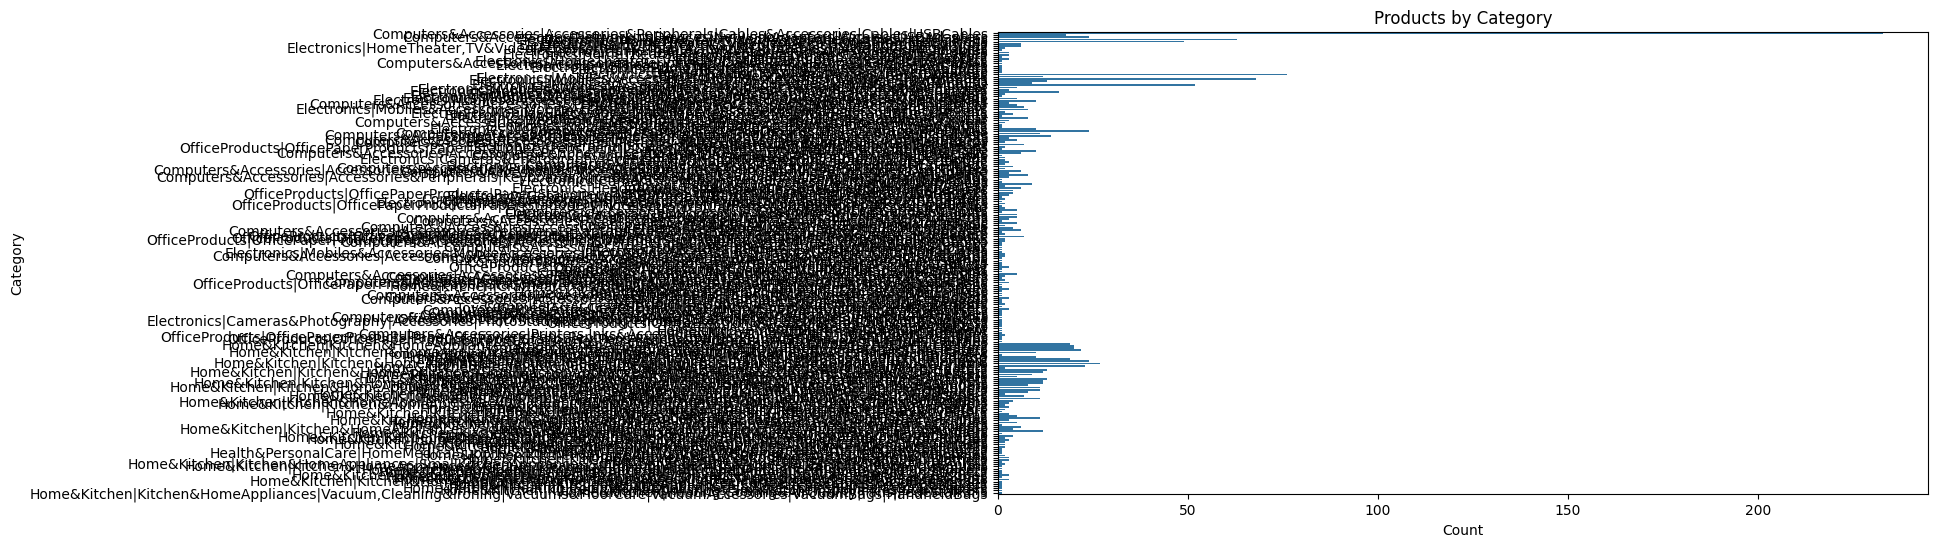

In [6]:
plt.figure(figsize=(12,6))

sns.countplot(y=df["category"])

plt.title("Products by Category")

plt.xlabel("Count")

plt.ylabel("Category")

plt.show()

## Observation:

- Shows which categories contain the most products.

## Chart 2: Top 10 Highest Rated Products

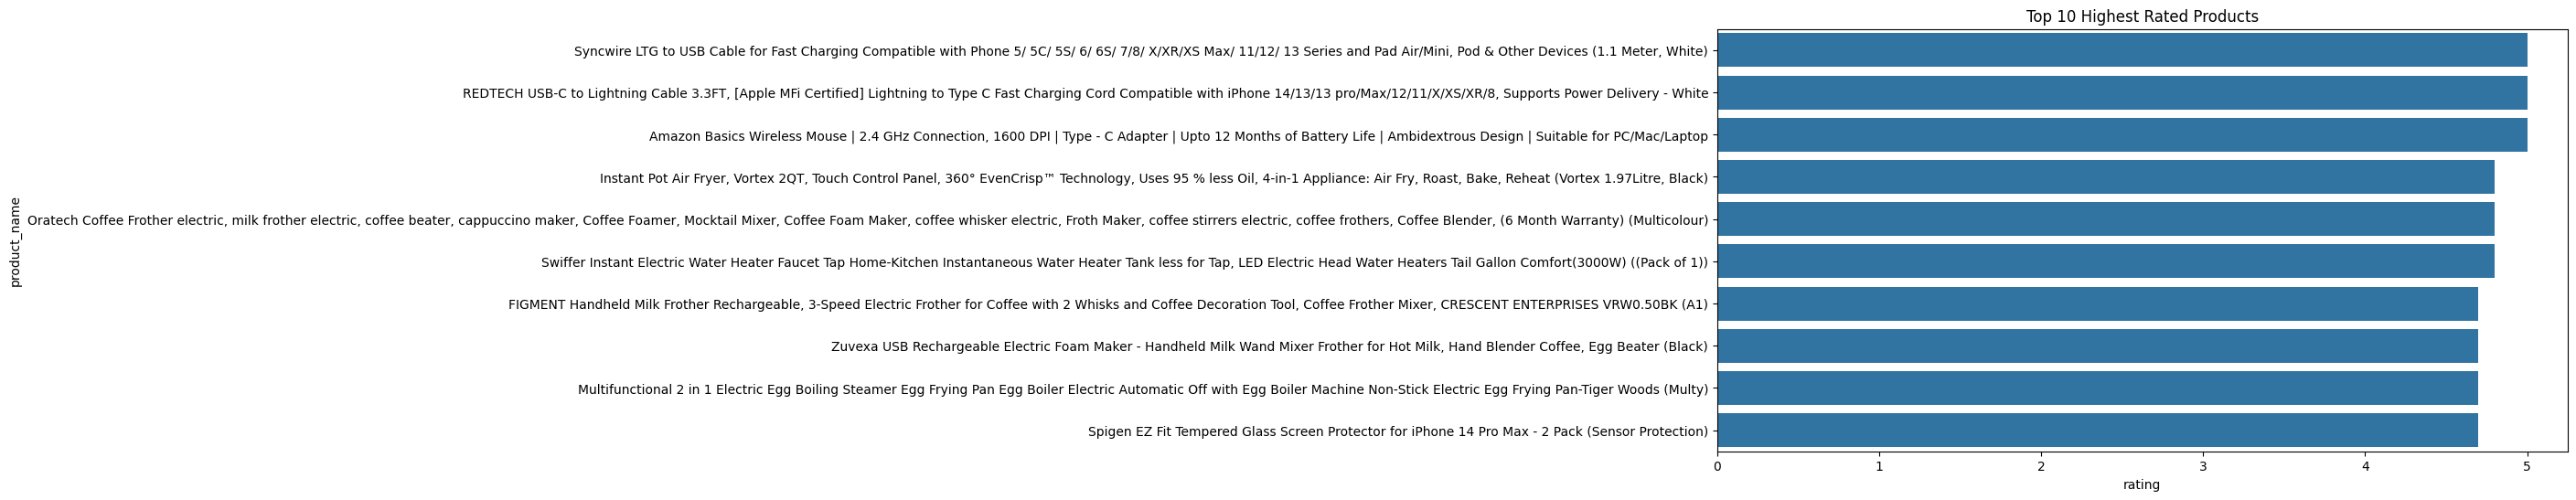

In [7]:
top10 = df.sort_values(
    by="rating",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="rating",
    y="product_name"
)

plt.title("Top 10 Highest Rated Products")

plt.show()

### Observation

- The chart displays the top 10 highest-rated products in the dataset.
- These products have received excellent customer ratings, indicating high customer satisfaction.
- Highly rated products are generally perceived as reliable and of good quality.

## Chart 3: Top 10 Products with Highest Discounts

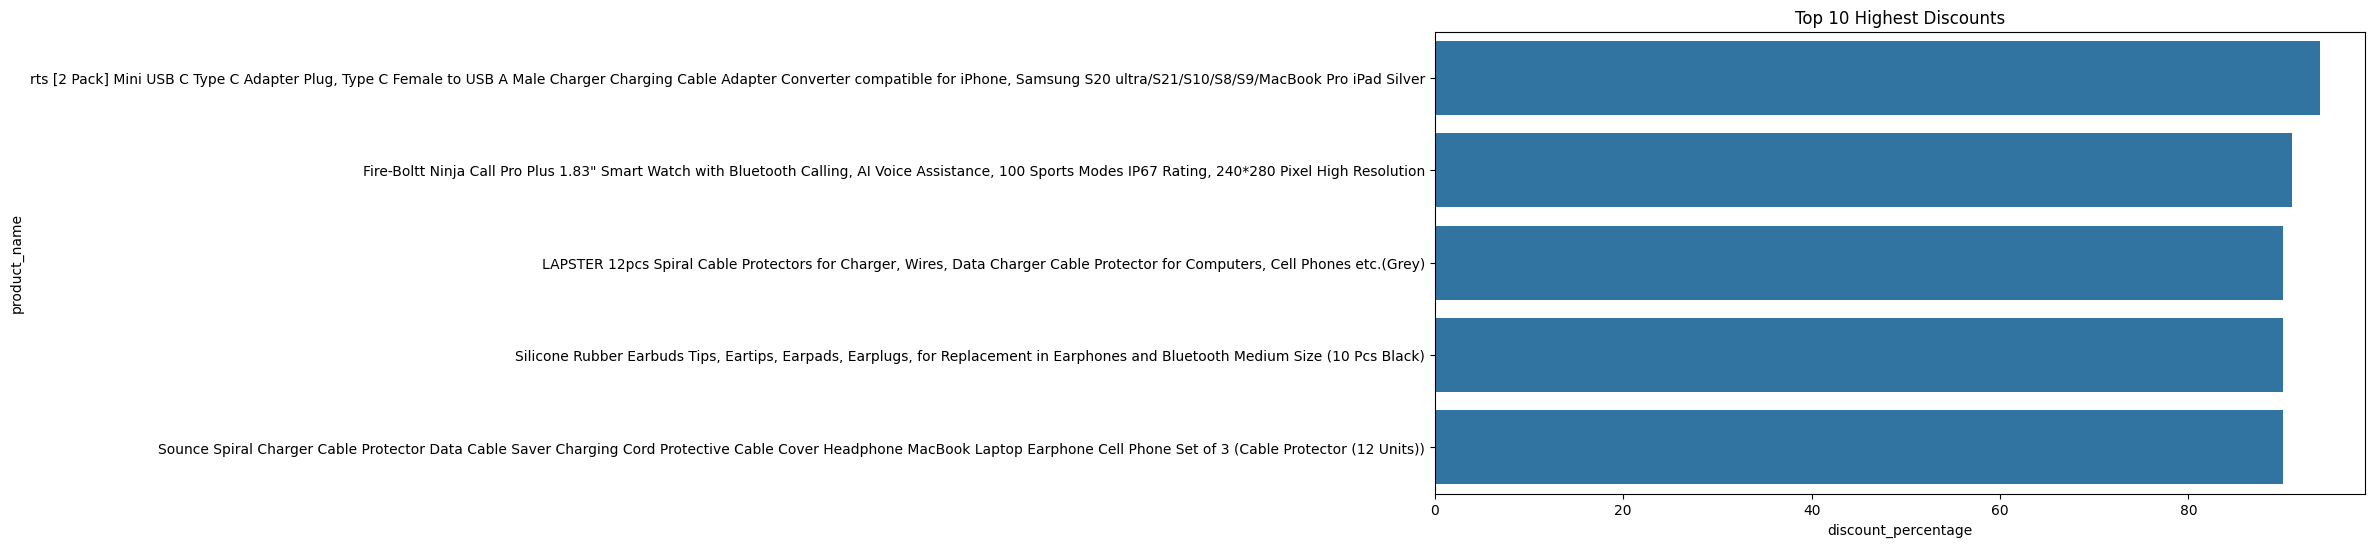

In [8]:
top_discount = df.sort_values(
    by="discount_percentage",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_discount,
    x="discount_percentage",
    y="product_name"
)

plt.title("Top 10 Highest Discounts")

plt.show()

### Observation

- The chart highlights the products offering the highest discount percentages.
- Several products provide substantial discounts, making them attractive to potential buyers.
- Large discounts may help increase customer interest and boost product sales.

## Chart 4: Actual Price vs Discounted Price

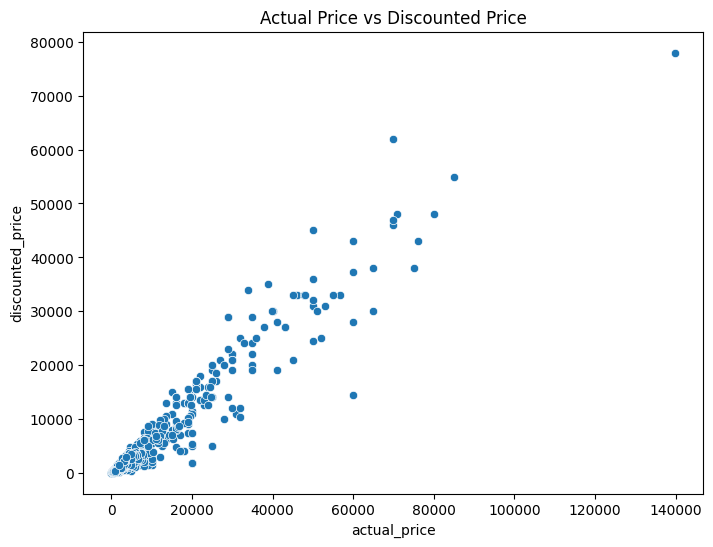

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="actual_price",
    y="discounted_price"
)

plt.title("Actual Price vs Discounted Price")

plt.show()

### Observation

- The scatter plot shows a positive relationship between the actual price and the discounted price.
- As the actual price of a product increases, its discounted price generally also increases.
- Most discounted prices remain below the actual prices, indicating that discounts are consistently applied across products.

## hart 5: Top 10 Most Reviewed Products

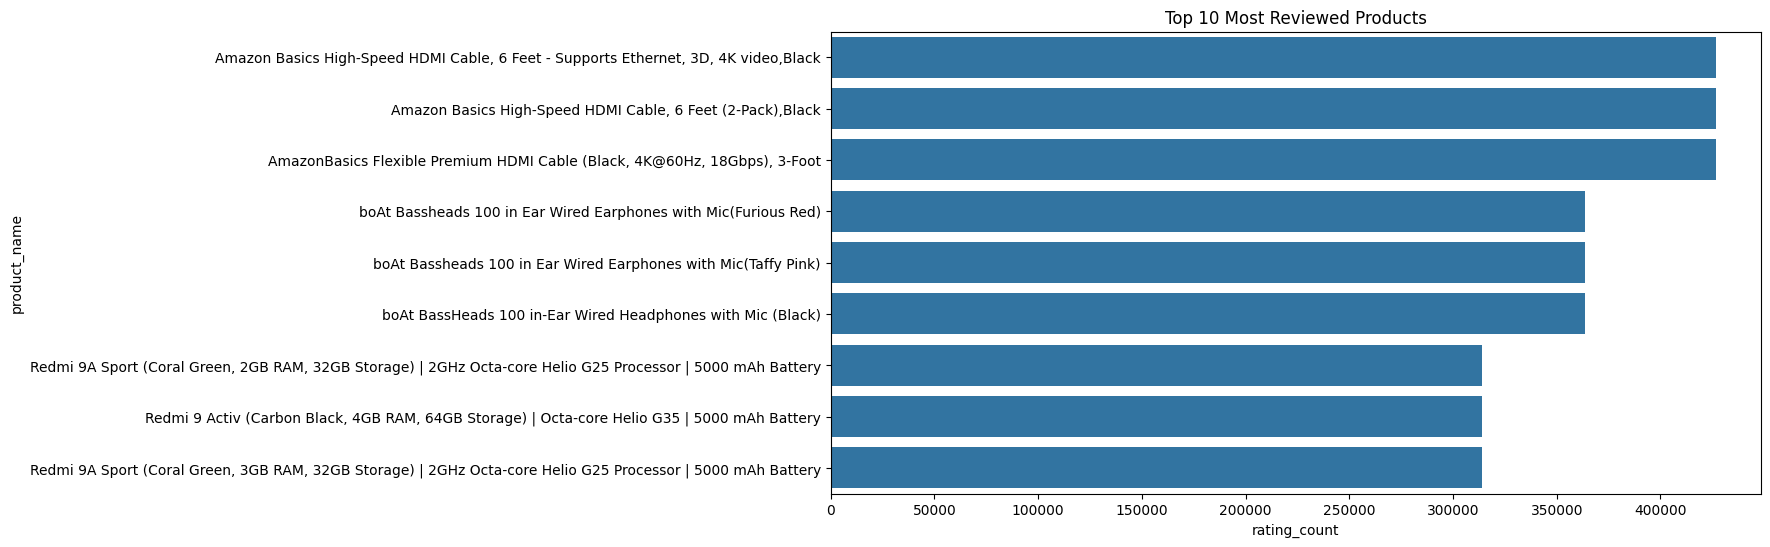

In [10]:
top_review = df.sort_values(
    by="rating_count",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_review,
    x="rating_count",
    y="product_name"
)

plt.title("Top 10 Most Reviewed Products")

plt.show()

### Observation

- The chart displays the products that have received the highest number of customer ratings.
- Products with a larger number of ratings are generally more popular and have higher customer engagement.
- A high rating count indicates that many customers have purchased and reviewed these products.

## Chart 6: Distribution of Top 5 Product Categories

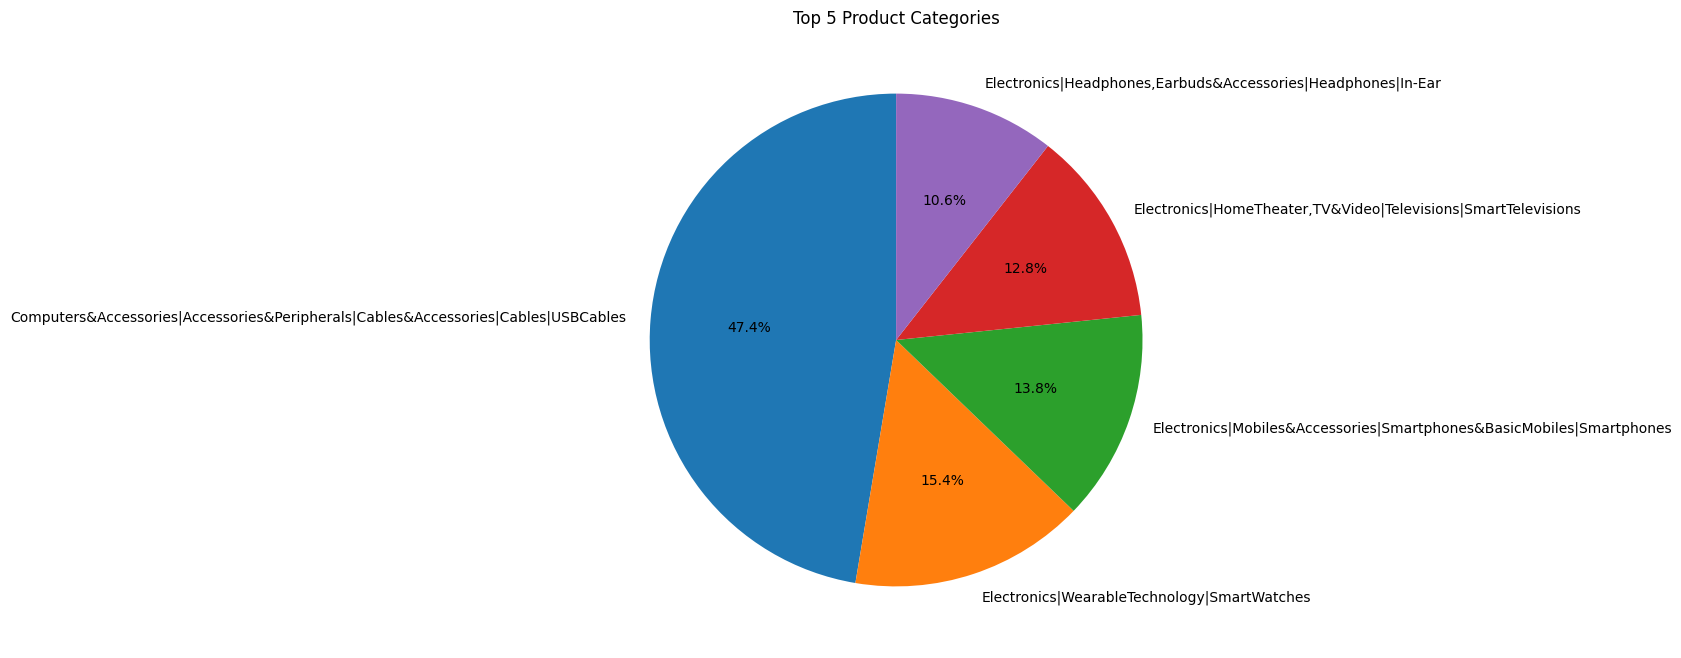

In [11]:
top_categories = df["category"].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top_categories,
    labels=top_categories.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Product Categories")

plt.show()

### Observation

- The pie chart illustrates the percentage distribution of the top five product categories.
- One or two categories contribute a major share of the products.
- This indicates that Amazon focuses more on these product categories.

## Chart 7: Distribution of Product Ratings

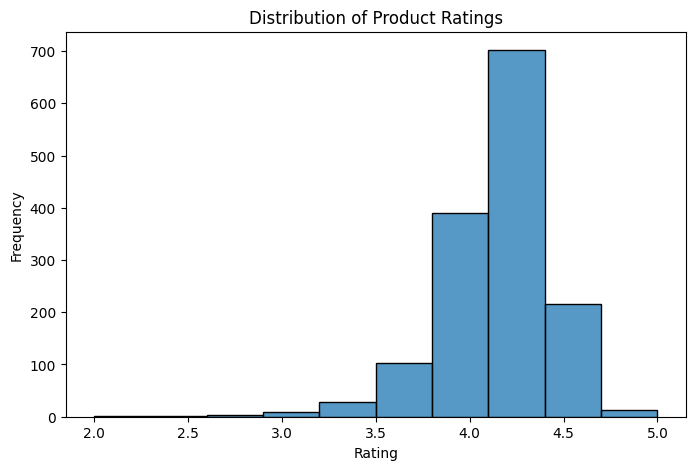

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["rating"], bins=10)

plt.title("Distribution of Product Ratings")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

### Observation

- The histogram shows how product ratings are distributed.
- Most products have ratings between 4 and 5.
- This suggests that the majority of products receive positive customer feedback.

## Chart 8: Distribution of Actual Prices

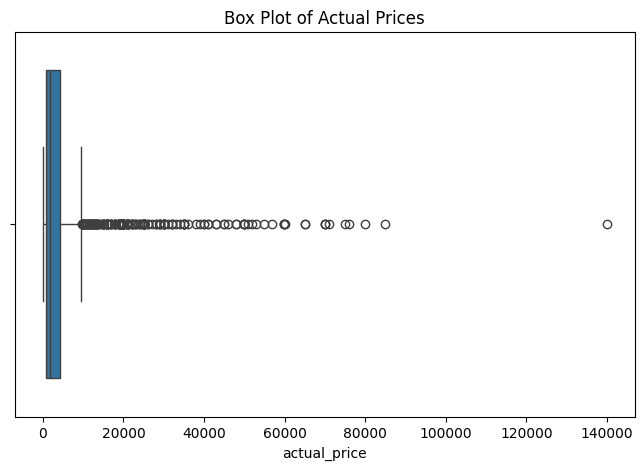

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["actual_price"])

plt.title("Box Plot of Actual Prices")

plt.show()

### Observation

- The box plot reveals the spread of actual product prices.
- Several outliers are visible, representing very expensive products.
- Most products fall within a moderate price range.

## Chart 9: Correlation Heatmap

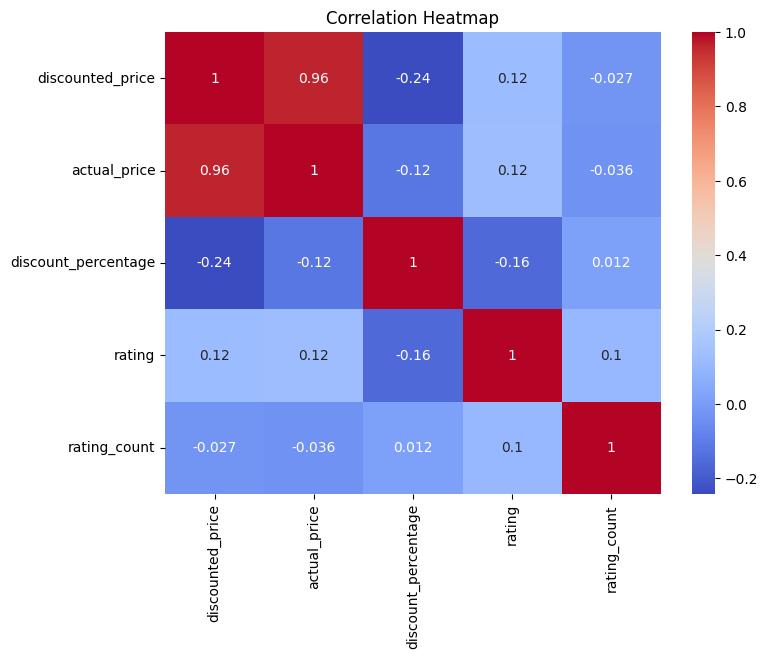

In [14]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The heatmap shows the correlation between numerical variables.
- Actual price and discounted price have a strong positive correlation.
- Correlation analysis helps identify relationships among variables.

## Chart 10: Distribution of Discount Percentage

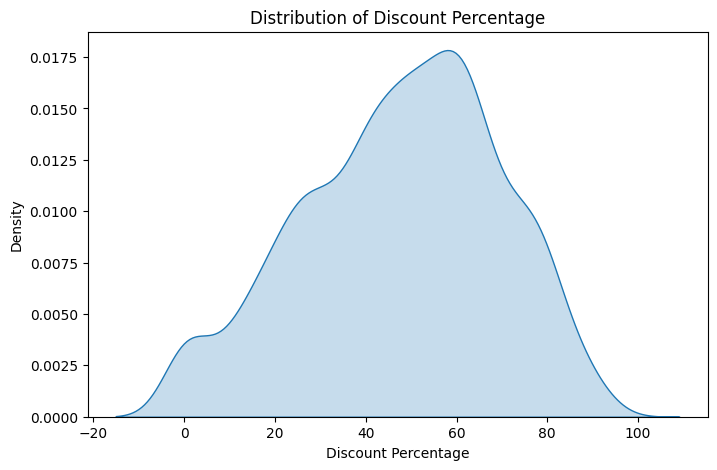

In [15]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["discount_percentage"], fill=True)

plt.title("Distribution of Discount Percentage")

plt.xlabel("Discount Percentage")

plt.show()

### Observation

- The distribution plot illustrates how discount percentages are spread across products.
- Most products have moderate discount percentages.
- Extremely high discounts are relatively uncommon.

# Data Story

The visualizations reveal valuable insights into the Amazon product dataset.

- Electronics dominate the dataset with the largest number of listed products.
- Highly rated products indicate strong customer satisfaction.
- Several products provide substantial discounts, making them attractive to buyers.
- A positive relationship exists between actual and discounted prices.
- Products with the highest rating counts are generally the most popular and trusted by customers.

These insights can help businesses understand customer preferences, optimize pricing strategies, and improve product recommendations.

# Key Insights

- Amazon offers products across multiple categories, with some categories containing significantly more products.
- Most products have high customer ratings, indicating positive customer experiences.
- A small number of products receive exceptionally high numbers of customer ratings, showing strong popularity.
- Higher-priced products generally have higher discounted prices, indicating a consistent pricing strategy.
- Several products provide substantial discounts, making them attractive to customers.
- Correlation analysis reveals a strong relationship between actual price and discounted price.
- Most product ratings are concentrated between 4 and 5 stars.
- Product prices vary widely, with a few premium products identified as outliers.
- Discount percentages are mostly moderate, with only a few products receiving exceptionally high discounts.
- Data visualization transforms raw data into meaningful insights that support business decision-making.

# Final Conclusion

This project successfully transformed raw Amazon product data into meaningful visualizations using Python, Matplotlib, and Seaborn. The analysis revealed product distribution, pricing patterns, customer ratings, and discount trends. These insights can help businesses make informed decisions related to pricing, marketing, and inventory management.